# Unit 1: Laboratorio - Filtros e Intuición de Convoluciones
## Implementar Filtros Manualmente y Visualizar Efectos de Convoluciones

**Objetivos del Laboratorio:**
1. Entender qué es un filtro (kernel) mediante manipulación directa
2. Implementar convoluciones manualmente
3. Experimentar con diferentes kernels
4. Crear un "filtro detector" simple para clasificar entre dos imágenes

**Entrega:** 
- Este notebook completado con todas las secciones
- Los kernels que creaste
- Explicación de cómo tu clasificador funciona

---

## Setup: Importar Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import signal
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo para mejor visualización
plt.style.use('default')
np.set_printoptions(precision=2, suppress=True)

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## Sección 1: Creación de Imágenes de Prueba

Vamos a crear dos imágenes diferentes que representan dos categorías que queremos distinguir.

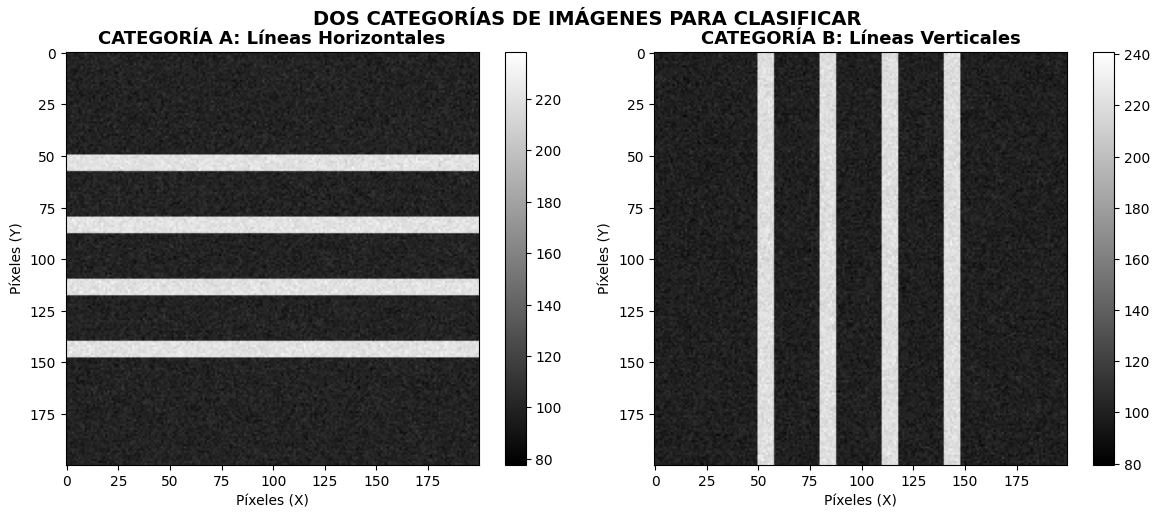

✓ Imágenes creadas:
  - Imagen A (Líneas Horizontales): (200, 200)
  - Imagen B (Líneas Verticales): (200, 200)


In [2]:
def crear_imagen_categoria_A(height=200, width=200, seed=42):
    """Crea una imagen que representa la CATEGORÍA A: Líneas Horizontales"""
    np.random.seed(seed)
    img = np.ones((height, width), dtype=np.float32) * 100
    
    # Agregar líneas horizontales claras
    for y in [50, 80, 110, 140]:
        img[y:y+8, :] = 220  # Líneas blancas
    
    # Agregar pequeño ruido gaussiano
    img += np.random.normal(0, 5, img.shape)
    
    return np.clip(img, 0, 255).astype(np.float32)

def crear_imagen_categoria_B(height=200, width=200, seed=43):
    """Crea una imagen que representa la CATEGORÍA B: Líneas Verticales"""
    np.random.seed(seed)
    img = np.ones((height, width), dtype=np.float32) * 100
    
    # Agregar líneas verticales claras
    for x in [50, 80, 110, 140]:
        img[:, x:x+8] = 220  # Líneas blancas
    
    # Agregar pequeño ruido gaussiano
    img += np.random.normal(0, 5, img.shape)
    
    return np.clip(img, 0, 255).astype(np.float32)

# Crear las imágenes
img_categoria_A = crear_imagen_categoria_A()
img_categoria_B = crear_imagen_categoria_B()

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(img_categoria_A, cmap='gray')
axes[0].set_title('CATEGORÍA A: Líneas Horizontales', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Píxeles (X)')
axes[0].set_ylabel('Píxeles (Y)')
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(img_categoria_B, cmap='gray')
axes[1].set_title('CATEGORÍA B: Líneas Verticales', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Píxeles (X)')
axes[1].set_ylabel('Píxeles (Y)')
plt.colorbar(im, ax=axes[1])

fig.suptitle('DOS CATEGORÍAS DE IMÁGENES PARA CLASIFICAR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Imágenes creadas:")
print(f"  - Imagen A (Líneas Horizontales): {img_categoria_A.shape}")
print(f"  - Imagen B (Líneas Verticales): {img_categoria_B.shape}")

## Sección 2: Entender Kernels - Experimento Guiado

Vamos a entender cómo diferentes kernels responden a las características de nuestras imágenes.


📊 Aplicando convoluciones...



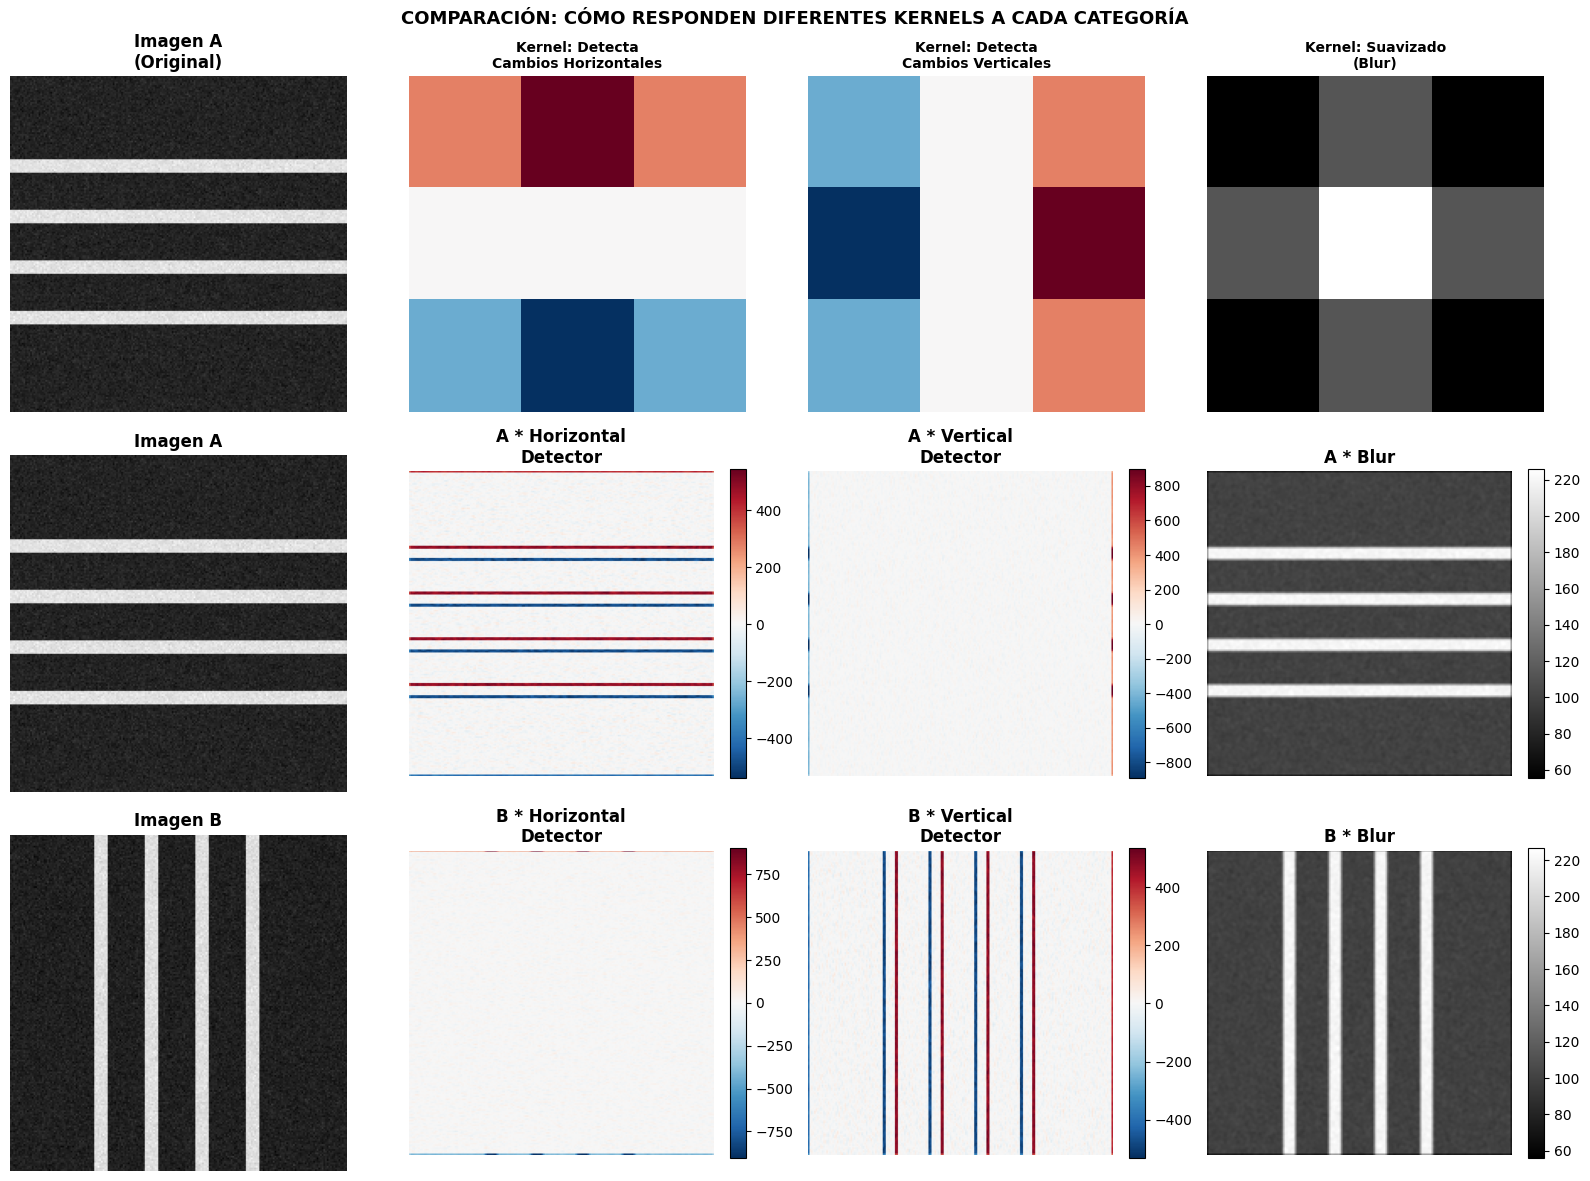


📈 ANÁLISIS DE RESPUESTAS:

Categoría A (Líneas Horizontales):
  - Detector Horizontal: Media=0.02, Max=546.36
  - Detector Vertical:   Media=0.00, Max=899.56
  - Suavizado:           Media=118.64, Max=226.11

Categoría B (Líneas Verticales):
  - Detector Horizontal: Media=-0.00, Max=903.87
  - Detector Vertical:   Media=0.02, Max=535.20
  - Suavizado:           Media=118.68, Max=226.62

✓ Observación: El detector de cambios horizontales responde MÁS a líneas horizontales
✓ Observación: El detector de cambios verticales responde MÁS a líneas verticales


In [3]:
# Definir algunos kernels básicos
kernel_detactor_horizontal = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

kernel_detector_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

kernel_suavizado = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16

# Aplicar convoluciones
print("\n📊 Aplicando convoluciones...\n")

# Categoría A con diferentes filtros
A_horizontal = signal.convolve2d(img_categoria_A, kernel_detactor_horizontal, mode='same')
A_vertical = signal.convolve2d(img_categoria_A, kernel_detector_vertical, mode='same')
A_suavizado = signal.convolve2d(img_categoria_A, kernel_suavizado, mode='same')

# Categoría B con diferentes filtros
B_horizontal = signal.convolve2d(img_categoria_B, kernel_detactor_horizontal, mode='same')
B_vertical = signal.convolve2d(img_categoria_B, kernel_detector_vertical, mode='same')
B_suavizado = signal.convolve2d(img_categoria_B, kernel_suavizado, mode='same')

# Visualizar resultados
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Fila 1: Original
axes[0, 0].imshow(img_categoria_A, cmap='gray')
axes[0, 0].set_title('Imagen A\n(Original)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(kernel_detactor_horizontal, cmap='RdBu_r')
axes[0, 1].set_title('Kernel: Detecta\nCambios Horizontales', fontweight='bold', fontsize=10)
axes[0, 1].axis('off')

axes[0, 2].imshow(kernel_detector_vertical, cmap='RdBu_r')
axes[0, 2].set_title('Kernel: Detecta\nCambios Verticales', fontweight='bold', fontsize=10)
axes[0, 2].axis('off')

axes[0, 3].imshow(kernel_suavizado, cmap='gray')
axes[0, 3].set_title('Kernel: Suavizado\n(Blur)', fontweight='bold', fontsize=10)
axes[0, 3].axis('off')

# Fila 2: Resultados Categoría A
axes[1, 0].imshow(img_categoria_A, cmap='gray')
axes[1, 0].set_title('Imagen A', fontweight='bold')
axes[1, 0].axis('off')

im = axes[1, 1].imshow(A_horizontal, cmap='RdBu_r')
axes[1, 1].set_title('A * Horizontal\nDetector', fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

im = axes[1, 2].imshow(A_vertical, cmap='RdBu_r')
axes[1, 2].set_title('A * Vertical\nDetector', fontweight='bold')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

im = axes[1, 3].imshow(A_suavizado, cmap='gray')
axes[1, 3].set_title('A * Blur', fontweight='bold')
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

# Fila 3: Resultados Categoría B
axes[2, 0].imshow(img_categoria_B, cmap='gray')
axes[2, 0].set_title('Imagen B', fontweight='bold')
axes[2, 0].axis('off')

im = axes[2, 1].imshow(B_horizontal, cmap='RdBu_r')
axes[2, 1].set_title('B * Horizontal\nDetector', fontweight='bold')
axes[2, 1].axis('off')
plt.colorbar(im, ax=axes[2, 1], fraction=0.046)

im = axes[2, 2].imshow(B_vertical, cmap='RdBu_r')
axes[2, 2].set_title('B * Vertical\nDetector', fontweight='bold')
axes[2, 2].axis('off')
plt.colorbar(im, ax=axes[2, 2], fraction=0.046)

im = axes[2, 3].imshow(B_suavizado, cmap='gray')
axes[2, 3].set_title('B * Blur', fontweight='bold')
axes[2, 3].axis('off')
plt.colorbar(im, ax=axes[2, 3], fraction=0.046)

fig.suptitle('COMPARACIÓN: CÓMO RESPONDEN DIFERENTES KERNELS A CADA CATEGORÍA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas
print("\n📈 ANÁLISIS DE RESPUESTAS:")
print("\nCategoría A (Líneas Horizontales):")
print(f"  - Detector Horizontal: Media={A_horizontal.mean():.2f}, Max={A_horizontal.max():.2f}")
print(f"  - Detector Vertical:   Media={A_vertical.mean():.2f}, Max={A_vertical.max():.2f}")
print(f"  - Suavizado:           Media={A_suavizado.mean():.2f}, Max={A_suavizado.max():.2f}")

print("\nCategoría B (Líneas Verticales):")
print(f"  - Detector Horizontal: Media={B_horizontal.mean():.2f}, Max={B_horizontal.max():.2f}")
print(f"  - Detector Vertical:   Media={B_vertical.mean():.2f}, Max={B_vertical.max():.2f}")
print(f"  - Suavizado:           Media={B_suavizado.mean():.2f}, Max={B_suavizado.max():.2f}")

print("\n✓ Observación: El detector de cambios horizontales responde MÁS a líneas horizontales")
print("✓ Observación: El detector de cambios verticales responde MÁS a líneas verticales")

## Sección 3: 🎯 EJERCICIO 1 - Crear tu Propio Kernel

Ahora es tu turno de crear kernels que mejor distingan entre las dos categorías.

**Instrucciones:**
1. Define un kernel de 3×3 que creas que será útil
2. Pruébalo en ambas imágenes
3. Analiza qué características detecta
4. Ajusta los valores si es necesario


📌 Tu Kernel 1:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


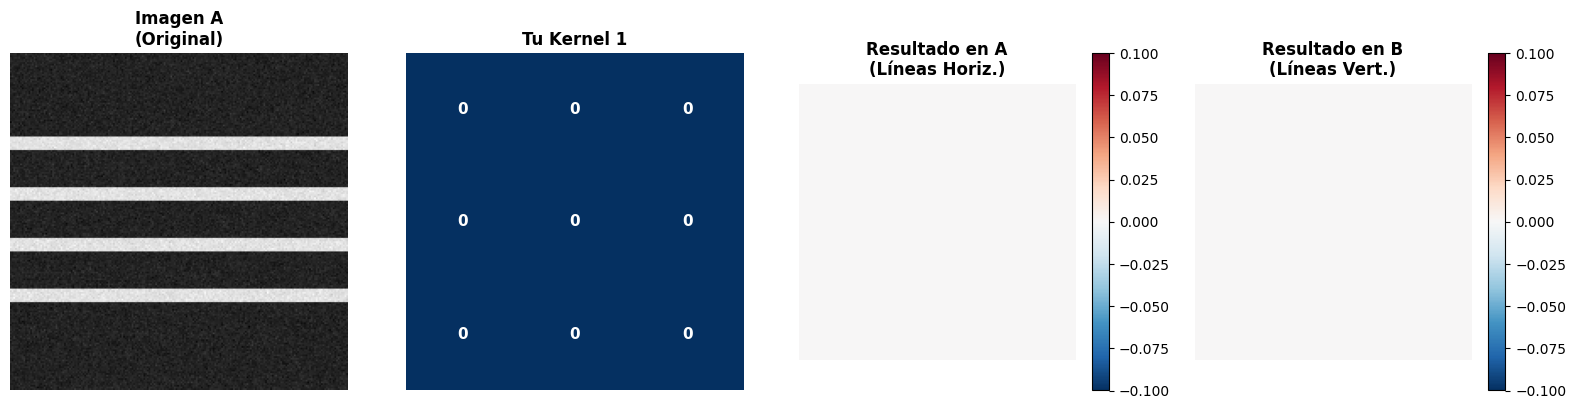


📊 ANÁLISIS DE TU KERNEL 1:
Respuesta en Imagen A: Media=0.00, Max=0.00, Min=0.00
Respuesta en Imagen B: Media=0.00, Max=0.00, Min=0.00

Diferencia de máximos: 0.00
⚠ Prueba ajustando los valores del kernel


In [ ]:
# 📝 CREA TU KERNEL AQUÍ
# Reemplaza los ceros con números que creas que funcionarán
# Puedes usar números negativos y positivos

mi_kernel_1 = np.array([
    [0, 0, 0],  # ← Cambia estos valores
    [0, 0, 0],  # ← Cambia estos valores
    [0, 0, 0]   # ← Cambia estos valores
], dtype=np.float32)

print("\n📌 Tu Kernel 1:")
print(mi_kernel_1)

# Aplicar tu kernel
resultado_A_kernel1 = signal.convolve2d(img_categoria_A, mi_kernel_1, mode='same') # mode 'same' para mantener tamaño
resultado_B_kernel1 = signal.convolve2d(img_categoria_B, mi_kernel_1, mode='same')

# Visualizar
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im = axes[0].imshow(img_categoria_A, cmap='gray')
axes[0].set_title('Imagen A\n(Original)', fontweight='bold')
axes[0].axis('off')

im = axes[1].imshow(mi_kernel_1, cmap='RdBu_r')
axes[1].set_title('Tu Kernel 1', fontweight='bold')
axes[1].axis('off')
for i in range(mi_kernel_1.shape[0]):
    for j in range(mi_kernel_1.shape[1]):
        axes[1].text(j, i, f'{mi_kernel_1[i,j]:.0f}', ha='center', va='center', 
                    fontsize=11, fontweight='bold', color='white')

im = axes[2].imshow(resultado_A_kernel1, cmap='RdBu_r')
axes[2].set_title('Resultado en A\n(Líneas Horiz.)', fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

im = axes[3].imshow(resultado_B_kernel1, cmap='RdBu_r')
axes[3].set_title('Resultado en B\n(Líneas Vert.)', fontweight='bold')
axes[3].axis('off')
plt.colorbar(im, ax=axes[3])

plt.tight_layout()
plt.show()

# Análisis
print("\n📊 ANÁLISIS DE TU KERNEL 1:")
print(f"Respuesta en Imagen A: Media={resultado_A_kernel1.mean():.2f}, Max={resultado_A_kernel1.max():.2f}, Min={resultado_A_kernel1.min():.2f}")
print(f"Respuesta en Imagen B: Media={resultado_B_kernel1.mean():.2f}, Max={resultado_B_kernel1.max():.2f}, Min={resultado_B_kernel1.min():.2f}")

dif_max = abs(resultado_A_kernel1.max() - resultado_B_kernel1.max())
print(f"\nDiferencia de máximos: {dif_max:.2f}")
if dif_max > 50:
    print("✓ ¡Buena separación entre categorías!")
else:
    print("⚠ Prueba ajustando los valores del kernel")

## Sección 4: 🎯 EJERCICIO 2 - Crear un Segundo Kernel

Crea un segundo kernel complementario que capture otras características.

In [ ]:
# 📝 CREA TU SEGUNDO KERNEL AQUÍ
mi_kernel_2 = np.array([
    [0, 0, 0],  # ← Cambia estos valores
    [0, 0, 0],  # ← Cambia estos valores
    [0, 0, 0]   # ← Cambia estos valores
], dtype=np.float32)

print("\n📌 Tu Kernel 2:")
print(mi_kernel_2)

# Aplicar tu kernel
resultado_A_kernel2 = signal.convolve2d(img_categoria_A, mi_kernel_2, mode='same')
resultado_B_kernel2 = signal.convolve2d(img_categoria_B, mi_kernel_2, mode='same')

# Visualizar
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im = axes[0].imshow(img_categoria_B, cmap='gray')
axes[0].set_title('Imagen B\n(Original)', fontweight='bold')
axes[0].axis('off')

im = axes[1].imshow(mi_kernel_2, cmap='RdBu_r')
axes[1].set_title('Tu Kernel 2', fontweight='bold')
axes[1].axis('off')
for i in range(mi_kernel_2.shape[0]):
    for j in range(mi_kernel_2.shape[1]):
        axes[1].text(j, i, f'{mi_kernel_2[i,j]:.0f}', ha='center', va='center', 
                    fontsize=11, fontweight='bold', color='white')

im = axes[2].imshow(resultado_A_kernel2, cmap='RdBu_r')
axes[2].set_title('Resultado en A\n(Líneas Horiz.)', fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

im = axes[3].imshow(resultado_B_kernel2, cmap='RdBu_r')
axes[3].set_title('Resultado en B\n(Líneas Vert.)', fontweight='bold')
axes[3].axis('off')
plt.colorbar(im, ax=axes[3])

plt.tight_layout()
plt.show()

# Análisis
print("\n📊 ANÁLISIS DE TU KERNEL 2:")
print(f"Respuesta en Imagen A: Media={resultado_A_kernel2.mean():.2f}, Max={resultado_A_kernel2.max():.2f}, Min={resultado_A_kernel2.min():.2f}")
print(f"Respuesta en Imagen B: Media={resultado_B_kernel2.mean():.2f}, Max={resultado_B_kernel2.max():.2f}, Min={resultado_B_kernel2.min():.2f}")

## Sección 5: 🎯 EJERCICIO 3 - Crear un Clasificador Simple

Combina tus dos kernels para crear un clasificador básico que distinga entre las dos categorías.

In [ ]:
def clasificar_imagen(imagen, kernel1, kernel2):
    """
    Clasifica una imagen como Categoría A o B usando dos kernels.
    
    Retorna:
    - score_A: Puntuación para categoría A
    - score_B: Puntuación para categoría B
    - clase: 'A' si score_A > score_B, 'B' en caso contrario
    """
    
    # Aplicar convoluciones
    resultado1 = signal.convolve2d(imagen, kernel1, mode='same')
    resultado2 = signal.convolve2d(imagen, kernel2, mode='same')
    
    # Calcular "energía" (suma de valores absolutos cuadrados)
    score_1 = np.sum(resultado1 ** 2)
    score_2 = np.sum(resultado2 ** 2)
    
    # Determinar clase
    # 📝 MODIFICA ESTA LÓGICA SI LO NECESITAS:
    if score_1 > score_2:
        clase = 'A'
    else:
        clase = 'B'
    
    return score_1, score_2, clase

# Probar el clasificador
print("\n🤖 PROBANDO EL CLASIFICADOR:")
print("\n" + "="*60)

# Clasificar imagen de categoría A
score_A1, score_A2, clase_A = clasificar_imagen(img_categoria_A, mi_kernel_1, mi_kernel_2)
print(f"\nImagen A (Líneas Horizontales):")
print(f"  Score Kernel 1: {score_A1:.2f}")
print(f"  Score Kernel 2: {score_A2:.2f}")
print(f"  ➜ Clasificada como: {clase_A}")
print(f"  ✓ CORRECTO" if clase_A == 'A' else f"  ✗ INCORRECTO")

# Clasificar imagen de categoría B
score_B1, score_B2, clase_B = clasificar_imagen(img_categoria_B, mi_kernel_1, mi_kernel_2)
print(f"\nImagen B (Líneas Verticales):")
print(f"  Score Kernel 1: {score_B1:.2f}")
print(f"  Score Kernel 2: {score_B2:.2f}")
print(f"  ➜ Clasificada como: {clase_B}")
print(f"  ✓ CORRECTO" if clase_B == 'B' else f"  ✗ INCORRECTO")

print("\n" + "="*60)

# Calcular precisión
aciertos = (clase_A == 'A') + (clase_B == 'B')
accuracy = aciertos / 2 * 100
print(f"\n📊 PRECISIÓN DEL CLASIFICADOR: {accuracy:.0f}%")

if accuracy == 100:
    print("🎉 ¡Perfecto! ¡Tu clasificador funciona correctamente!")
elif accuracy == 50:
    print("⚠️  Necesitas mejorar los kernels. No está mejor que un clasificador aleatorio.")
else:
    print("✓ Buen progreso. Puedes intentar mejorar los kernels.")

## Sección 6: 📊 Visualizar el Espacio de Características

Veamos cómo tus kernels transforman las imágenes en un "espacio de características".

## 📝 SECCIÓN 7: INFORME FINAL

Completa este informe explicando tu trabajo:

### Responde las siguientes preguntas:

**1. ¿Qué valores pusiste en tu Kernel 1 y por qué?**

```
Mi Kernel 1:
[ ?,  ?,  ? ]
[ ?,  ?,  ? ]
[ ?,  ?,  ? ]

Razón:
[Tu respuesta aquí]
```

---

**2. ¿Qué valores pusiste en tu Kernel 2 y por qué?**

```
Mi Kernel 2:
[ ?,  ?,  ? ]
[ ?,  ?,  ? ]
[ ?,  ?,  ? ]

Razón:
[Tu respuesta aquí]
```

---

**3. ¿Cómo funciona tu clasificador?**

```
[Explica en 3-4 líneas cómo combinas los kernels para clasificar]
```

---

**4. ¿Qué patrones detecta cada kernel?**

```
Kernel 1 detecta:
[Tu respuesta aquí]

Kernel 2 detecta:
[Tu respuesta aquí]
```

---

**5. Si tu clasificador no fue 100% acertado, ¿qué cambiarías?**

```
[Tu respuesta aquí]
```

---

**6. Conexión con CNNs: ¿Cómo se relaciona esto con redes neuronales convolucionales?**

```
[En 3-4 líneas, explica cómo este ejercicio te ayuda a entender las capas de convolución en CNNs]
```

---

### Lo que aprendiste:

1. ✅ **Un filtro (kernel) es una pequeña matriz** que detecta patrones específicos
2. ✅ **Diferentes kernels detectan diferentes características** (bordes horizontales, verticales, etc.)
3. ✅ **La convolución es el producto punto** entre el kernel y la región de la imagen
4. ✅ **Múltiples kernels pueden combinarse** para crear un clasificador
5. ✅ **En CNNs, el sistema APRENDE automáticamente** qué kernels son útiles

### Próxima clase:
Ahora que entiendes filtros, veremos cómo **redes neuronales convolucionales** usan capas de convolución para extraer características automáticamente y resolver problemas complejos de visión por computadora.

---

**Entrega:**
- [ ] Este notebook completado con todas las secciones
- [ ] Informe final rellenado
- [ ] Los kernels que creaste y explicación de su funcionamiento
- [ ] Curso en DataCAmp